<!-- colab-badge-top -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/02_lvk_signals_injections.ipynb)

# Part 2A: LVK signals, injections, and matched filtering

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**


## Goal and route

Follow a compact-binary signal from source parameters through a detector network, injection, matched filtering, and a manual likelihood.

> **Live route**
>
> Follow the source -> detector -> search -> inference path. Stop after the one-parameter network posterior; degeneracies and localisation are read-later extensions.

**Animation guide.** The four animations have separate jobs: chirp-mass error
accumulates phase, orbital motion produces a chirp, a matched filter finds the
correct time shift, and a moving sky position changes the detector-network
response. The first and third are quantitative within this setup; the orbital
cartoon is labelled as intuition rather than a waveform model.

### Three questions that must stay separate

| Stage | Question | Output |
| --- | --- | --- |
| search | is there a candidate unlike ordinary noise? | trigger and ranking statistic |
| parameter estimation | which source parameters remain plausible? | posterior and credible intervals |
| population inference | what population produced many detected events? | selection-aware population model |

This notebook moves from the first question to the second; module 04 asks the
third. **A large matched-filter SNR is not a parameter posterior, and not an
astrophysical detection probability.**

Green is nature's forward problem; blue is ours. Reading the blue arrow right
to left gives the rest of this course: detect a signal, work out what sang it,
then ask what the whole chorus looks like.

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/gw_inverse_problem.png" alt="Populations of black holes emit gravitational waves that reach Earth; we invert that chain by detecting, identifying, and then characterising the population" style="max-width:100%">

In [1]:
import os, sys, subprocess, importlib.util

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
missing = [
    p for p in ("ripplegw", "bilby", "gwpy") if importlib.util.find_spec(p) is None
]
if missing:
    if IN_COLAB:
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "rippleGW==0.2.1",
                "bilby==2.8.0",
                "gwpy>=3.0,<4",
            ]
        )
    else:
        raise ImportError(
            "Install rippleGW==0.2.1, bilby==2.8.0, and gwpy>=3.0,<4, or run in Colab."
        )

In [2]:
import logging
import numpy as np
import matplotlib.pyplot as plt
import bilby
from gwpy.timeseries import TimeSeries
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation
from jax import config

config.update("jax_enable_x64", True)
import jax.numpy as jnp
from ripplegw.conversions import ms_to_Mc_eta
from ripplegw.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc

logging.getLogger("bilby").setLevel(logging.ERROR)
plt.style.use("seaborn-v0_8-whitegrid")


def show_animation(animation):
    # H.264 video: ~40x smaller in the notebook than one PNG per frame
    try:
        return display(HTML(animation.to_html5_video()))
    except RuntimeError:  # ffmpeg unavailable: fall back to per-frame PNGs
        return display(HTML(animation.to_jshtml()))


rng = np.random.default_rng(20260817)

from matplotlib.ticker import NullFormatter, ScalarFormatter


def tidy_log_frequency(axis, ticks=(20, 50, 100, 200, 500)):
    """Readable Hz labels: matplotlib's log minor ticks overlap on wide bands."""
    axis.set_xticks(list(ticks))
    axis.xaxis.set_major_formatter(ScalarFormatter())
    axis.xaxis.set_minor_formatter(NullFormatter())

/Users/avi/Documents/projects/WORKSHOP/FQCP2026_GW_data_analysis/.venv/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


## 1. CBC parameters

A binary black hole needs **15 parameters**; a binary neutron star needs more.
Every one of them is something a sampler has to explore, so the count is a cost.
Splitting them into *intrinsic* (what the source is) and *extrinsic* (where it
is and how it is oriented) is useful bookkeeping — but note that they stay
correlated in the posterior regardless.

$$
\mathcal M=\frac{(m_1m_2)^{3/5}}{(m_1+m_2)^{1/5}},\qquad
m_{\rm detector}=(1+z)m_{\rm source}.
$$

#### Intrinsic — what the source *is*

These set the phase evolution.

- **Mass — 2D.** Usually uniform in two mass parameters. Component masses
  $(m_1,m_2)$ are widely used; chirp mass and mass ratio are a more convenient
  basis, because $\mathcal M$ is what the inspiral phase actually measures.
  Normally quoted in the **detector frame**, redshifted relative to the true
  source-frame mass.
- **Dimensionless spin — 6D.** Three components each. Analyses pick one of:
  - *fully precessing* — uniform in magnitude, isotropic in orientation
    (see the animation below);
  - *aligned spin only* — planar components set to zero, same prior on the
    aligned component;
  - *zero spin* — a much smaller space to sample, and what this notebook and
    module 03 use.
- **Orbital eccentricity — 1D/2D.** Eccentricity and argument of periastron.
  Usually ignored, because most sources circularise long before they reach the
  band.
- **Matter effects (neutron stars) — 2D or more.** Two tidal deformabilities
  $\Lambda_i$, or a variable number of equation-of-state parameters — zero of
  them if the equation of state is held fixed.

#### Extrinsic — where it is, and how it is oriented

These set what the detectors actually see.

- **Location — 3D.** Right ascension, declination, luminosity distance.
  Usually isotropic over the sky, with a distance prior uniform in volume
  (which should include cosmological effects). A known host galaxy replaces
  this with something far tighter — as for GW170817.
- **Orientation — 4D.** Three Euler angles (phase, inclination, polarisation),
  assumed isotropically distributed.
- **Merger time — 1D.** Uniform over the expected uncertainty in the trigger
  time, typically $\sim 0.1$ s.

### What precession looks like

When the spins are not aligned with the orbital angular momentum, the orbital
plane itself precesses. The waveform amplitude and phase are then modulated on
the precession timescale — which is why "fully precessing" costs six spin
parameters instead of one, and why it is the first thing dropped when a fast
answer is needed.

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/precessing_binary.gif" alt="A precessing binary black hole: the orbital plane tumbles, modulating the emitted h+ and hx" style="max-width:70%">

*Numerical-relativity surrogate `NRSur7dq2`, with the remnant from
`surfinBH7dq2`. Top: the orbital plane and spin vectors. Bottom: the two
polarisations the detector would see.*

In [3]:
sample_rate, duration, f_min = 1024, 4, 20.0
gps_time = 1126259462.4
frequency = np.fft.rfftfreq(int(sample_rate * duration), 1 / sample_rate)
mask = frequency >= f_min
df = frequency[1] - frequency[0]


def ripple_parameters(
    chirp_mass=None,
    m1=36.0,
    m2=29.0,
    chi1=0.1,
    chi2=-0.1,
    distance=800.0,
    tc=0.0,
    phase=0.3,
    inclination=0.5,
):
    mc, eta = ms_to_Mc_eta(jnp.array([m1, m2]))
    mc = mc if chirp_mass is None else chirp_mass
    return jnp.array([mc, eta, chi1, chi2, distance, tc, phase, inclination])


def polarizations(theta):
    hp, hx = gen_IMRPhenomD_hphc(jnp.asarray(frequency[mask]), theta, f_min)
    result = {
        "plus": np.zeros(frequency.size, dtype=complex),
        "cross": np.zeros(frequency.size, dtype=complex),
    }
    result["plus"][mask] = np.asarray(hp)
    result["cross"][mask] = np.asarray(hx)
    return result


theta_true = ripple_parameters()
injection_polarizations = polarizations(theta_true)
print(f"Detector-frame chirp mass: {float(theta_true[0]):.3f} solar masses")

Detector-frame chirp mass: 28.096 solar masses


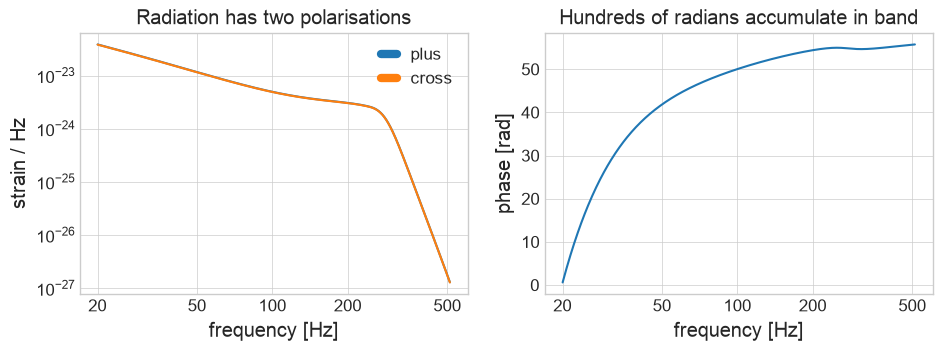

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for name, h in injection_polarizations.items():
    axes[0].loglog(frequency[mask], np.abs(h[mask]), label=name)
axes[0].set(
    xlabel="frequency [Hz]",
    ylabel="strain / Hz",
    title="Radiation has two polarisations",
)
axes[0].legend()
axes[1].semilogx(
    frequency[mask], np.unwrap(np.angle(injection_polarizations["plus"][mask]))
)
axes[1].set(
    xlabel="frequency [Hz]",
    ylabel="phase [rad]",
    title="Hundreds of radians accumulate in band",
)
for ax in axes:
    tidy_log_frequency(ax)
plt.show()

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-network-response.png" alt="expected output: lvk-network-response" style="max-width:100%">

</details>

For a non-precessing circular binary, approximately
$h_+\propto(1+\cos^2\iota)/(2D_L)$ and $h_\times\propto\cos\iota/D_L$.
Inclination is the binary's orientation to us; polarisation angle rotates the plus/cross basis on the sky.

### Animation: why chirp mass is measured so precisely

The signal accumulates hundreds of radians of phase in band, so a wrong chirp
mass shows up as **dephasing**, not as a wrong amplitude.

A template is free to slide in time and shift its overall phase, and matched
filtering maximises over both. So the fair comparison removes a linear-in-$f$
term first:

$$
\Delta\psi(f)=\psi_{\mathcal M}(f)-\psi_{\mathcal M_{\rm true}}(f)
-\underbrace{(a f+b)}_{\text{absorbed by }t_c,\ \phi_c}.
$$

What is left cannot be absorbed and is what destroys the match.

- Left: the amplitude barely moves. You could not measure $\mathcal M$ this way.
- Right: the residual dephasing. Once $|\Delta\psi|$ exceeds about 1 radian
  (grey band) the template and signal drift out of step and the recovered SNR
  falls, as Section 3 will show directly.

In [5]:
mass_offsets = np.linspace(-2.0, 2.0, 21)
mc_true = float(theta_true[0])
f_band = frequency[mask]
reference = injection_polarizations["plus"][mask]
reference_phase = np.unwrap(np.angle(reference))
# Weight the tc/phi_c fit by signal power so it reflects where the SNR is.
weight = np.abs(reference) ** 2
basis = np.vstack([f_band, np.ones_like(f_band)]).T
weighted_basis = basis * np.sqrt(weight)[:, None]

fig, (amp_ax, phase_ax) = plt.subplots(1, 2, figsize=(11, 3.5), dpi=80)
amp_ax.loglog(f_band, np.abs(reference), color="0.7", lw=3, label="injection")
(amp_line,) = amp_ax.loglog([], [], color="C0", label="trial template")
amp_ax.set(
    xlim=(20, 512),
    ylim=(1e-25, 3e-22),
    xlabel="frequency [Hz]",
    ylabel=r"$|h_+|$",
    title="amplitude: almost no information",
)
amp_ax.legend(loc="lower left", fontsize=8)

phase_ax.axhspan(-1, 1, color="0.8", alpha=0.7)
phase_ax.axhline(0, color="k", lw=0.8)
(phase_line,) = phase_ax.semilogx([], [], color="C3")
phase_ax.set(
    xlim=(20, 512),
    ylim=(-10, 10),
    xlabel="frequency [Hz]",
    ylabel=r"$\Delta\psi$ [rad]",
    title="residual dephasing: all the information",
)
for ax in (amp_ax, phase_ax):
    tidy_log_frequency(ax)
fig.subplots_adjust(top=0.80, wspace=0.28)


def animate_mass(i):
    trial = polarizations(theta_true.at[0].set(mc_true + mass_offsets[i]))["plus"][mask]
    difference = np.unwrap(np.angle(trial)) - reference_phase
    coefficients = np.linalg.lstsq(
        weighted_basis, difference * np.sqrt(weight), rcond=None
    )[0]
    residual = difference - basis @ coefficients
    amp_line.set_data(f_band, np.abs(trial))
    phase_line.set_data(f_band, residual)
    fig.suptitle(
        f"chirp mass error {mass_offsets[i]:+.2f} solar masses "
        f"({100 * mass_offsets[i] / mc_true:+.1f}%), "
        f"peak dephasing {np.abs(residual).max():.1f} rad"
    )
    return amp_line, phase_line


mass_animation = FuncAnimation(
    fig, animate_mass, frames=len(mass_offsets), interval=160
)
plt.close(fig)
show_animation(mass_animation)

### Fast inspiral cartoon—physics intuition, not numerical relativity

This deliberately cheap animation connects orbital motion to a chirping quadrupole signal. It is not a surrogate or merger-remnant prediction: the actual waveform animation above is the quantitative one.

In [6]:
cartoon_time = np.linspace(0, 1, 40)
radius = 1 - 0.82 * cartoon_time
orbital_phase = 2 * np.pi * (1.3 * cartoon_time + 5 * cartoon_time**3)
x = radius * np.cos(orbital_phase)
y = radius * np.sin(orbital_phase)
cartoon_strain = (1 / radius) * np.cos(2 * orbital_phase)
cartoon_strain /= np.max(np.abs(cartoon_strain))
fig, (orbit_ax, strain_ax) = plt.subplots(1, 2, figsize=(10, 4))
(body_1,) = orbit_ax.plot([], [], "o", ms=9, color="C0")
(body_2,) = orbit_ax.plot([], [], "o", ms=7, color="C1")
(separation,) = orbit_ax.plot([], [], color="0.6")
(strain_line,) = strain_ax.plot([], [], color="C3")
(marker,) = strain_ax.plot([], [], "o", color="C3")
orbit_ax.set(
    xlim=(-1.1, 1.1),
    ylim=(-1.1, 1.1),
    aspect="equal",
    xlabel="x [cartoon]",
    ylabel="y [cartoon]",
    title="shrinking, accelerating orbit",
)
strain_ax.set(
    xlim=(0, 1),
    ylim=(-1.1, 1.1),
    xlabel="time to merger [cartoon]",
    ylabel="normalised strain",
    title="frequency and amplitude increase",
)


def animate_inspiral(i):
    body_1.set_data([x[i]], [y[i]])
    body_2.set_data([-x[i]], [-y[i]])
    separation.set_data([-x[i], x[i]], [-y[i], y[i]])
    strain_line.set_data(cartoon_time[: i + 1], cartoon_strain[: i + 1])
    marker.set_data([cartoon_time[i]], [cartoon_strain[i]])
    return body_1, body_2, separation, strain_line, marker


inspiral_animation = FuncAnimation(
    fig, animate_inspiral, frames=len(cartoon_time), interval=55
)
plt.close(fig)
show_animation(inspiral_animation)

## 2. From source to a detector network

Each detector sees one projected combination of the two polarisations, delayed
by its own light-travel time:

$$
\tilde h_I=\left[F^I_+(\alpha,\delta,\psi,t)\,h_+
+F^I_\times(\alpha,\delta,\psi,t)\,h_\times\right]e^{-2\pi if\Delta t_I}.
$$

If the detector noises are independent given their PSDs, the network likelihood
is a product, so log-likelihoods simply add:

$$
\log\mathcal L_{\rm net}=\sum_I\log\mathcal L_I
=-\frac12\sum_I(d_I-h_I\mid d_I-h_I)_I+C.
$$

- $F_+^I,F_\times^I$ depend on sky position, polarisation, detector
  orientation, and sidereal time. Bilby stores the geometry and applies this.
- $\Delta t_I$ is the arrival-time delay, and differences between detectors are
  what localise the source (Section 5).
- **Source parameters are shared**; only the response and the noise weighting
  are detector-specific. That is the whole reason a network beats one detector.
- Adding a detector adds its $(d\mid h)$ terms, so SNRs add in quadrature.

In [7]:
source_parameters = dict(ra=1.2, dec=-0.4, psi=0.7, geocent_time=gps_time)
ifos = bilby.gw.detector.InterferometerList(["H1", "L1", "V1"])
for ifo in ifos:
    ifo.set_strain_data_from_zero_noise(
        sampling_frequency=sample_rate, duration=duration, start_time=gps_time - 2
    )
print("IFO     F+      Fx      delay [ms]")
for ifo in ifos:
    fp = ifo.antenna_response(
        source_parameters["ra"],
        source_parameters["dec"],
        gps_time,
        source_parameters["psi"],
        "plus",
    )
    fx = ifo.antenna_response(
        source_parameters["ra"],
        source_parameters["dec"],
        gps_time,
        source_parameters["psi"],
        "cross",
    )
    dt = ifo.time_delay_from_geocenter(
        source_parameters["ra"], source_parameters["dec"], gps_time
    )
    print(f"{ifo.name:>3}  {fp:+.3f}  {fx:+.3f}   {1e3*dt:+.2f}")

IFO     F+      Fx      delay [ms]
 H1  +0.366  +0.334   -3.18
 L1  -0.263  -0.597   -11.80
 V1  +0.108  -0.159   +3.83


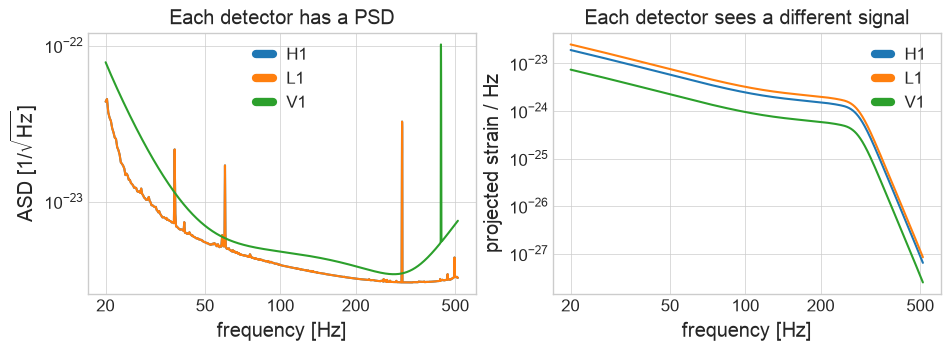

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ifo in ifos:
    asd = ifo.power_spectral_density.get_amplitude_spectral_density_array(frequency)
    axes[0].loglog(frequency[mask], asd[mask], label=ifo.name)
    response = ifo.get_detector_response(
        injection_polarizations, source_parameters, frequencies=frequency
    )
    axes[1].loglog(frequency[mask], np.abs(response[mask]), label=ifo.name)
axes[0].set(
    xlabel="frequency [Hz]",
    ylabel=r"ASD [1/$\sqrt{\mathrm{Hz}}$]",
    title="Each detector has a PSD",
)
axes[1].set(
    xlabel="frequency [Hz]",
    ylabel="projected strain / Hz",
    title="Each detector sees a different signal",
)
for ax in axes:
    tidy_log_frequency(ax)
    ax.legend()
plt.show()

## 3. Finding the signal first: matched filtering

Before anyone estimates parameters, something has to notice that a signal is
there. In real strain data a loud binary is still far below the noise: the
whitened signal peaks at a few tenths of the noise standard deviation, so no
amount of staring at the time series will show it.

The optimal linear filter for a *known* waveform in Gaussian noise is the
matched filter. Slide a normalised template through the data and record the
overlap as a function of trial coalescence time $\tau$:

$$
z(\tau)=\frac{(d\mid h_\tau)}{\sqrt{(h\mid h)}},\qquad
h_\tau(f)=h(f)\,e^{-2\pi i f\tau}.
$$

Because the time shift is only a phase ramp in frequency, the whole SNR time
series comes from a single inverse FFT rather than one integral per trial time.
Two numbers matter, and they are not the same:

- the **optimal SNR** $\rho_{\rm opt}=\sqrt{(h\mid h)}$, what a perfect template
  would achieve on average;
- the **matched-filter SNR**, the value actually recovered, which scatters about
  $\rho_{\rm opt}$ and is biased high at the peak because we maximised over
  $\tau$.

Searches repeat this over a bank of $\sim10^6$ templates. Parameter estimation
then starts from the resulting trigger.

H1: optimal SNR 20.87 | recovered peak 21.74 at +0.0000 s
L1: optimal SNR 27.37 | recovered peak 27.96 at +0.0000 s
V1: optimal SNR  6.24 | recovered peak  5.92 at +0.0000 s


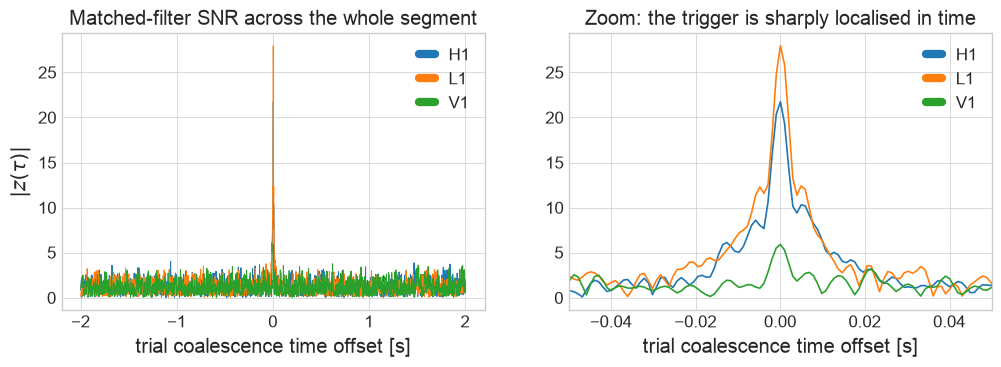

In [9]:
bilby.core.utils.random.seed(2026)
noisy_ifos = bilby.gw.detector.InterferometerList(["H1", "L1", "V1"])
for ifo in noisy_ifos:
    ifo.set_strain_data_from_power_spectral_density(
        sampling_frequency=sample_rate, duration=duration, start_time=gps_time - 2
    )
    ifo.inject_signal_from_waveform_polarizations(
        source_parameters, injection_polarizations
    )

n_samples = int(sample_rate * duration)
segment_time = np.arange(n_samples) / sample_rate  # seconds after segment start
# fftshift puts zero trial offset in the middle: bilby already places the
# merger at geocent_time, so the peak should land at an offset of zero.
trial_offset = (np.arange(n_samples) - n_samples // 2) / sample_rate


def matched_filter(ifo, template_polarizations):
    """Return the SNR time series and the optimal SNR for one detector."""
    template = ifo.get_detector_response(
        template_polarizations, source_parameters, frequencies=frequency
    )
    psd = ifo.power_spectral_density_array
    usable = mask & np.isfinite(psd) & (psd > 0)
    integrand = np.zeros(frequency.size, dtype=complex)
    integrand[usable] = (
        ifo.frequency_domain_strain[usable] * np.conj(template[usable]) / psd[usable]
    )
    padded = np.zeros(n_samples, dtype=complex)
    padded[: integrand.size] = integrand
    z = 4 * df * n_samples * np.fft.ifft(padded)
    optimal = np.sqrt(4 * df * np.sum(np.abs(template[usable]) ** 2 / psd[usable]))
    return np.fft.fftshift(np.abs(z)) / optimal, optimal


fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ifo in noisy_ifos:
    snr_series, optimal_snr = matched_filter(ifo, injection_polarizations)
    peak = np.argmax(snr_series)
    axes[0].plot(trial_offset, snr_series, lw=0.7, label=ifo.name)
    axes[1].plot(trial_offset, snr_series, lw=1.2, label=ifo.name)
    print(
        f"{ifo.name}: optimal SNR {optimal_snr:5.2f} | "
        f"recovered peak {snr_series[peak]:5.2f} at "
        f"{trial_offset[peak]:+.4f} s"
    )
axes[0].set(
    xlabel="trial coalescence time offset [s]",
    ylabel=r"$|z(\tau)|$",
    title="Matched-filter SNR across the whole segment",
)
axes[1].set(
    xlim=(-0.05, 0.05),
    xlabel="trial coalescence time offset [s]",
    title="Zoom: the trigger is sharply localised in time",
)
for ax in axes:
    ax.legend()
plt.show()

### Animation: sliding the template through whitened data

- Whitening divides each Fourier bin by the noise ASD, so every frequency
  carries comparable noise. This is the weighting the likelihood applies.
- Left: the whitened template slides across the whitened H1 data.
  Right: the SNR that the overlap produces at each shift.
- The signal is invisible by eye, yet the filter finds it: the template adds
  the signal **coherently** over hundreds of cycles while noise adds
  incoherently. That is the $\sqrt{N_{\rm cycles}}$ gain.

**Predict before running:** Why can the filter find a signal that is
invisible by eye in the whitened data, and why would an incorrect phase
evolution stop that coherent accumulation?

In [10]:
def whiten(frequency_series, psd):
    usable = mask & np.isfinite(psd) & (psd > 0)
    whitened = np.zeros(frequency.size, dtype=complex)
    whitened[usable] = frequency_series[usable] / np.sqrt(psd[usable] / (4 * df))
    return np.fft.irfft(whitened, n=n_samples)


h1 = noisy_ifos[0]
h1_psd = h1.power_spectral_density_array
whitened_data = whiten(h1.frequency_domain_strain, h1_psd)
whitened_template = whiten(
    h1.get_detector_response(
        injection_polarizations, source_parameters, frequencies=frequency
    ),
    h1_psd,
)
h1_snr_series, _ = matched_filter(h1, injection_polarizations)

lags = np.linspace(-0.3, 0.3, 45)
window = (segment_time > 1.3) & (segment_time < 2.35)

fig, (data_ax, snr_ax) = plt.subplots(1, 2, figsize=(10.5, 3.6), dpi=72)
data_ax.plot(segment_time[window], whitened_data[window], lw=0.6, color="0.55")
(template_line,) = data_ax.plot([], [], lw=1.4, color="C3")
data_ax.set(
    xlabel="time after segment start [s]",
    ylabel="whitened strain",
    title="whitened H1 data (grey) and trial template (red)",
)
(snr_trace,) = snr_ax.plot([], [], color="C0")
(snr_head,) = snr_ax.plot([], [], "o", color="C3")
snr_ax.set(
    xlim=(lags[0], lags[-1]),
    ylim=(0, 1.1 * h1_snr_series.max()),
    xlabel="template time shift [s]",
    ylabel=r"$|z(\tau)|$",
    title="overlap accumulated by the filter",
)
fig.subplots_adjust(top=0.78, wspace=0.28)


def animate_filter(i):
    shift = int(round(lags[i] * sample_rate))
    shifted = np.roll(whitened_template, shift)
    template_line.set_data(segment_time[window], shifted[window])
    used = trial_offset <= lags[i]
    snr_trace.set_data(trial_offset[used], h1_snr_series[used])
    snr_value = np.interp(lags[i], trial_offset, h1_snr_series)
    snr_head.set_data([lags[i]], [snr_value])
    fig.suptitle(f"time shift {lags[i]:+.3f} s, SNR {snr_value:.1f}")
    return template_line, snr_trace, snr_head


filter_animation = FuncAnimation(fig, animate_filter, frames=len(lags), interval=110)
plt.close(fig)
show_animation(filter_animation)

### A template only works if it is close enough

- A search cannot use the true waveform: the true parameters are what we are
  looking for. It uses a **bank** of templates and hopes one is close enough.
- Below, the same data are filtered with deliberately wrong chirp masses.
- How fast the recovered SNR falls sets how densely the bank must be packed.
  Banks are built to lose no more than a few percent of SNR anywhere.
- Compare with the dephasing animation in Section 1: the SNR loss here is that
  dephasing, integrated over the band.

### Code studio: build a tiny template bank

Write a function that loops over chirp-mass offsets, builds each trial waveform,
runs `matched_filter`, and stores the largest recovered SNR. Use only the
objects already defined above. The peak should lie close to zero offset.

In [11]:
def student_template_bank_scan(offsets):
    # YOUR CODE HERE
    return None


student_bank = student_template_bank_scan(np.linspace(-2, 2, 9))
if student_bank is None:
    print("Your turn: return one peak SNR for every trial chirp-mass offset.")
else:
    student_bank = np.asarray(student_bank)
    assert student_bank.shape == (9,)
    best_offset = np.linspace(-2, 2, 9)[np.argmax(student_bank)]
    assert abs(best_offset) <= 0.5
    print(f"check passed; best template offset = {best_offset:+.1f} solar masses")

Your turn: return one peak SNR for every trial chirp-mass offset.


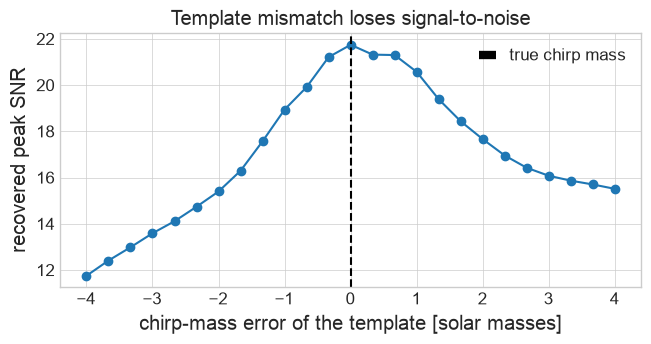

In [12]:
mismatch_offsets = np.linspace(-4, 4, 25)
recovered_peaks = []
for offset in mismatch_offsets:
    trial = polarizations(theta_true.at[0].set(float(theta_true[0]) + offset))
    snr_series, _ = matched_filter(h1, trial)
    recovered_peaks.append(snr_series.max())

fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.plot(mismatch_offsets, recovered_peaks, "o-")
ax.axvline(0, color="k", ls="--", label="true chirp mass")
ax.set(
    xlabel="chirp-mass error of the template [solar masses]",
    ylabel="recovered peak SNR",
    title="Template mismatch loses signal-to-noise",
)
ax.legend()
plt.show()

### Question: how densely must a bank be packed?

A search bank is built so that it loses no more than a few percent of SNR
*anywhere*, including at the worst point between two neighbouring templates.
The scan above measured exactly that loss curve, so you can now size a bank
from it. Use `mismatch_offsets` and `recovered_peaks`.

1. How wide is the peak at 97% of the maximum recovered SNR?
2. A bank whose spacing equals that full width puts its worst case exactly
   halfway between templates. What spacing is that, and how many templates
   would it take to cover $\mathcal M\in[20,40]\,M_\odot$?
3. Real banks tile several parameters at once, and the count multiplies with
   each one. What does that imply about the cost of a search?

In [13]:
# Your code here. `mismatch_offsets` and `recovered_peaks` come from the scan
# above; no new waveform calls are needed.

<details>
<summary>Hint</summary>

The quantity that sets the spacing is the width of the matched-filter peak,
not the number of templates you happened to try. Find the offsets whose
recovered SNR is still within 3% of the maximum.

</details>


## 4. Inject and infer manually

We free only the detector-frame chirp mass $\mathcal M$:

$$
p(\mathcal M\mid d)\propto \pi(\mathcal M)
\exp\!\left[-\frac12\sum_I
(d_I-h_I(\mathcal M)\mid d_I-h_I(\mathcal M))_I\right].
$$

- The waveform changes once, then is projected into H1, L1, and Virgo.
- Independent detector log likelihoods add to form the network likelihood.
- We use zero-noise data so the width is deterministic; the PSD still sets the
  expected uncertainty.
- The grid is deliberately zoomed to $\pm0.1\,M_\odot$. On the old wide scale
  both posteriors were visually indistinguishable spikes.

Replace `set_strain_data_from_zero_noise` with Bilby's PSD-noise method to study
scatter across noise realisations.

Network optimal SNR: 34.98


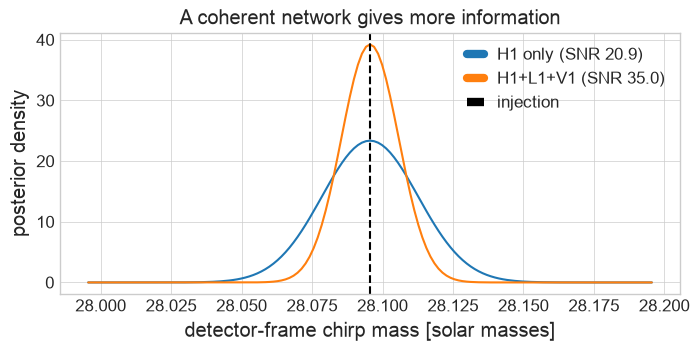

sigma, H1 only : 0.0171 solar masses
sigma, network : 0.0102 solar masses
width ratio    : 1.68
SNR ratio      : 1.68  <- posterior width scales as 1/SNR


In [14]:
for ifo in ifos:
    ifo.inject_signal_from_waveform_polarizations(
        source_parameters, injection_polarizations
    )
print(
    "Network optimal SNR:",
    round(np.sqrt(sum(ifo.meta_data["optimal_SNR"] ** 2 for ifo in ifos)), 2),
)


def detector_log_likelihood(ifo, model_polarizations):
    model = ifo.get_detector_response(
        model_polarizations, source_parameters, frequencies=frequency
    )
    residual = ifo.frequency_domain_strain - model
    psd = ifo.power_spectral_density_array
    return -2 * df * np.sum(np.abs(residual[mask]) ** 2 / psd[mask])


# The chirp mass is measured to ~0.01 solar masses, so the grid must be narrow.
# A +/-2 solar mass window would be about 120 sigma wide and show only a spike.
mass_grid = np.linspace(float(theta_true[0]) - 0.1, float(theta_true[0]) + 0.1, 141)
logL_by_ifo = {ifo.name: [] for ifo in ifos}
for mc in mass_grid:
    model = polarizations(theta_true.at[0].set(mc))
    for ifo in ifos:
        logL_by_ifo[ifo.name].append(detector_log_likelihood(ifo, model))
logL_network = np.sum([logL_by_ifo[name] for name in logL_by_ifo], axis=0)


def density(logp):
    p = np.exp(logp - np.max(logp))
    return p / np.trapezoid(p, mass_grid)


log_prior_mass = np.where(
    (mass_grid >= mass_grid[0]) & (mass_grid <= mass_grid[-1]), 0.0, -np.inf
)
posterior_h1 = density(np.array(logL_by_ifo["H1"]) + log_prior_mass)
posterior_network = density(logL_network + log_prior_mass)


def summarise(density_values):
    mean = np.trapezoid(density_values * mass_grid, mass_grid)
    return np.sqrt(np.trapezoid(density_values * (mass_grid - mean) ** 2, mass_grid))


sd_h1 = summarise(posterior_h1)
sd_network = summarise(posterior_network)
snr_h1 = ifos[0].meta_data["optimal_SNR"]
snr_network = np.sqrt(sum(ifo.meta_data["optimal_SNR"] ** 2 for ifo in ifos))

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(mass_grid, posterior_h1, label=f"H1 only (SNR {snr_h1:.1f})")
ax.plot(mass_grid, posterior_network, label=f"H1+L1+V1 (SNR {snr_network:.1f})")
ax.axvline(float(theta_true[0]), color="k", ls="--", label="injection")
ax.set(
    xlabel="detector-frame chirp mass [solar masses]",
    ylabel="posterior density",
    title="A coherent network gives more information",
)
ax.legend()
plt.show()

print(f"sigma, H1 only : {sd_h1:.4f} solar masses")
print(f"sigma, network : {sd_network:.4f} solar masses")
print(f"width ratio    : {sd_h1/sd_network:.2f}")
print(f"SNR ratio      : {snr_network/snr_h1:.2f}  <- posterior width scales as 1/SNR")

### Put the same likelihood behind Bilby's interface

- A Bilby likelihood is just a class with a `log_likelihood` method and a
  declared parameter set. Nothing is hidden.
- Here Bilby wraps the **exact** network calculation written above.
- The assertion checks the library interface against the manual values, so the
  transition from hand-rolled to production code is verified, not assumed.

In [15]:
class ChirpMassLikelihood(bilby.Likelihood):
    def __init__(self):
        super().__init__()

    def log_likelihood(self, parameters=None):
        trial_theta = theta_true.at[0].set(parameters["chirp_mass"])
        trial_polarizations = polarizations(trial_theta)
        return sum(detector_log_likelihood(ifo, trial_polarizations) for ifo in ifos)


bilby_likelihood = ChirpMassLikelihood()
bilby_priors = {
    "chirp_mass": bilby.core.prior.Uniform(
        minimum=mass_grid[0],
        maximum=mass_grid[-1],
        name="chirp_mass",
        unit="solar masses",
    )
}

bilby_log_likelihood = []
for chirp_mass in mass_grid:
    bilby_log_likelihood.append(
        bilby_likelihood.log_likelihood(parameters={"chirp_mass": chirp_mass})
    )

np.testing.assert_allclose(bilby_log_likelihood, logL_network)
print("Bilby likelihood agrees with the manual network calculation.")
print("Prior:", bilby_priors["chirp_mass"])

Bilby likelihood agrees with the manual network calculation.
Prior: Uniform(minimum=np.float64(27.99555579546043), maximum=np.float64(28.195555795460432), name='chirp_mass', latex_label='$\\mathcal{M}$', unit='solar masses', boundary=None)


> **End of the live route**
>
> You have followed one coherent chain: a physical waveform was projected into
> detectors, found with a matched filter, and used in a network likelihood. The
> sections below show two important complications but are not required for a
> first pass.

## Read later: degeneracies and sky localisation

### Extension: all-sky network sensitivity

**Predict before running:** Does adding a detector make every sky direction
equally loud, or does it mainly fill particular blind spots? Which information
needed for localisation is absent from a sensitivity map?

Each detector's polarisation-averaged sensitivity to a direction is

$$
R_I(\alpha,\delta)=\sqrt{F_+^{I\,2}+F_\times^{I\,2}},\qquad
\text{network proxy}=\sqrt{\sum_I\left(\frac{R_I}{\mathrm{ASD}_I}\right)^2}.
$$

- $R_I$ is **independent of the polarisation angle** $\psi$: rotating $\psi$
  mixes $F_+$ and $F_\times$ but preserves this combination.
- A single interferometer has a quadrupolar pattern with four blind spots.
  Watch how the three individual maps put their blind spots in *different*
  places, so the network map is far more uniform.
- The proxy is noise-weighted with each ASD at 100 Hz. It is not a real SNR:
  that also needs the waveform, distance, inclination, and full PSD.
- A sensitivity map says how *loud* a source is, not *where* it is. Localisation
  comes from arrival-time and phase differences, which Section 5 covers.

In [16]:
sky_ra = np.linspace(-np.pi, np.pi, 73)
sky_dec = np.linspace(-np.pi / 2, np.pi / 2, 37)
sky_ra_grid, sky_dec_grid = np.meshgrid(sky_ra, sky_dec)
reference_frequency = 100.0
reference_index = np.argmin(np.abs(frequency - reference_frequency))
asd_reference = np.array(
    [
        ifo.power_spectral_density.get_amplitude_spectral_density_array(frequency)[
            reference_index
        ]
        for ifo in ifos
    ]
)


def response_and_snr_proxy(ra, dec):
    responses = []
    for ifo in ifos:
        f_plus = ifo.antenna_response(
            ra, dec, gps_time, source_parameters["psi"], "plus"
        )
        f_cross = ifo.antenna_response(
            ra, dec, gps_time, source_parameters["psi"], "cross"
        )
        responses.append(np.hypot(f_plus, f_cross))
    responses = np.asarray(responses)
    return responses, np.sqrt(np.sum((responses / asd_reference) ** 2, axis=0))


# Per-detector response maps and the noise-weighted network proxy.
detector_maps = np.array(
    [
        [[response_and_snr_proxy(ra, dec)[0][k] for ra in sky_ra] for dec in sky_dec]
        for k in range(len(ifos))
    ]
)
snr_proxy_map = np.array(
    [[response_and_snr_proxy(ra, dec)[1] for ra in sky_ra] for dec in sky_dec]
)
snr_proxy_scale = snr_proxy_map.max()
detector_names = [ifo.name for ifo in ifos]

detector_scales = detector_maps.max(axis=(1, 2))
panels = [
    (name, detector_maps[k] / detector_scales[k])
    for k, name in enumerate(detector_names)
]
panels.append(("network", snr_proxy_map / snr_proxy_scale))

# Four reasonably sized maps reveal the blind spots more clearly than one
# compressed row. The bar chart answers the local question at the marker.
fig = plt.figure(figsize=(12, 6.8), dpi=78)
grid_spec = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.72], hspace=0.24, wspace=0.16)
markers = []
map_axes = []
for panel_index, (name, field) in enumerate(panels):
    row, column = divmod(panel_index, 2)
    sky_ax = fig.add_subplot(grid_spec[row, column], projection="mollweide")
    map_axes.append(sky_ax)
    image = sky_ax.pcolormesh(
        sky_ra_grid, sky_dec_grid, field, shading="auto", cmap="viridis", vmin=0, vmax=1
    )
    (marker,) = sky_ax.plot([], [], "o", color="C3", mec="white", ms=7)
    markers.append(marker)
    sky_ax.grid(True, lw=0.4, alpha=0.5)
    sky_ax.set_xticklabels([])
    sky_ax.set_yticklabels([])
    sky_ax.set_title(
        f"{name} blind spots" if name != "network" else "network (noise-weighted)",
        fontsize=10,
    )
fig.colorbar(
    image,
    ax=map_axes,
    location="bottom",
    pad=0.08,
    shrink=0.72,
    label="normalised response",
)

sky_ra_frames = np.linspace(-np.pi, np.pi, 24, endpoint=False)
response_ax = fig.add_subplot(grid_spec[:, 2])
bars = response_ax.bar(
    [*detector_names, "network"],
    np.zeros(4),
    color=["C0", "C1", "C2", "0.25"],
)
response_ax.set(
    ylim=(0, 1.05),
    ylabel="normalised response at marker",
    title="what this sky position gives",
)
response_ax.tick_params(axis="x", rotation=30)


def animate_sky_response(frame):
    source_ra = sky_ra_frames[frame]
    for marker in markers:
        marker.set_data([source_ra], [source_parameters["dec"]])
    responses, network_response = response_and_snr_proxy(
        source_ra, source_parameters["dec"]
    )
    values = np.r_[responses / detector_scales, network_response / snr_proxy_scale]
    for bar, value in zip(bars, values):
        bar.set_height(value)
    fig.suptitle(
        f"source at right ascension {source_ra:+.2f} rad; "
        f"network proxy {values[-1]:.2f}"
    )
    return (*markers, *bars)


response_animation = FuncAnimation(
    fig, animate_sky_response, frames=len(sky_ra_frames), interval=140
)
plt.close(fig)
show_animation(response_animation)

### A two-dimensional posterior with a real degeneracy

**Predict before running:** If we double the distance, which change in
inclination could approximately restore the observed amplitude? What feature
should that create in the joint posterior?

A one-parameter scan hides the feature that dominates real CBC results:
parameters are correlated, and some are correlated so strongly that they are
effectively measured only in combination.

The classic example is distance and inclination. For the dominant quadrupole
mode of a circular binary,

$$
h_+\propto\frac{1+\cos^2\iota}{2D_L},\qquad
h_\times\propto\frac{\cos\iota}{D_L},
$$

so both parameters enter only as amplitudes. Moving the source further away and
tilting it face-on both make the signal louder or quieter in nearly the same
way. This is why gravitational-wave distances are much less precise than
chirp masses, and why standard-siren cosmology cares so much about breaking it.

Because inclination and distance affect IMRPhenomD only through these
prefactors, we can rescale the injected polarisations instead of regenerating
the waveform, which makes a two-dimensional grid cheap. The cell asserts that
this shortcut reproduces rippleGW exactly.

Two caveats worth carrying forward. This grid uses a **flat prior on distance**
for simplicity; a real analysis uses a uniform-in-comoving-volume prior, which
grows like $D_L^2$ and therefore pushes the posterior towards larger distances.
And the posterior is one-sided in inclination here because we restricted
$\iota\le\pi/2$; the full problem is also nearly symmetric under
$\iota\rightarrow\pi-\iota$, giving the familiar two-lobed structure.

In [17]:
true_distance, true_inclination = 800.0, 0.5


def scaled_polarizations(distance, inclination):
    """Rescale the injection to a new distance and inclination."""
    plus_ratio = ((1 + np.cos(inclination) ** 2) / 2) / (
        (1 + np.cos(true_inclination) ** 2) / 2
    )
    cross_ratio = np.cos(inclination) / np.cos(true_inclination)
    distance_ratio = true_distance / distance
    return {
        "plus": injection_polarizations["plus"] * plus_ratio * distance_ratio,
        "cross": injection_polarizations["cross"] * cross_ratio * distance_ratio,
    }


# The shortcut must agree with a full rippleGW call.
check = polarizations(ripple_parameters(distance=1300.0, inclination=0.9))
shortcut = scaled_polarizations(1300.0, 0.9)
for polarisation in ("plus", "cross"):
    np.testing.assert_allclose(
        shortcut[polarisation][mask], check[polarisation][mask], rtol=1e-10
    )
print("Amplitude rescaling reproduces rippleGW to machine precision.")

distance_grid = np.linspace(450, 1250, 70)
inclination_grid = np.linspace(0.02, np.pi / 2 - 0.02, 66)
logL_grid = np.array(
    [
        [
            sum(
                detector_log_likelihood(
                    ifo, scaled_polarizations(distance, inclination)
                )
                for ifo in ifos
            )
            for inclination in inclination_grid
        ]
        for distance in distance_grid
    ]
)

joint_posterior = np.exp(logL_grid - logL_grid.max())
joint_posterior /= np.trapezoid(
    np.trapezoid(joint_posterior, inclination_grid, axis=1), distance_grid
)
distance_marginal = np.trapezoid(joint_posterior, inclination_grid, axis=1)
inclination_marginal = np.trapezoid(joint_posterior, distance_grid, axis=0)

Amplitude rescaling reproduces rippleGW to machine precision.


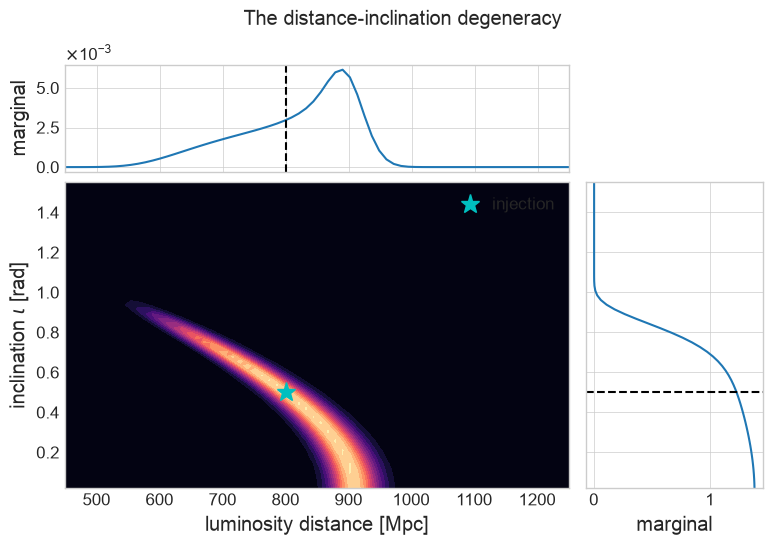

injected distance : 800 Mpc
posterior median  : 840 Mpc
90% interval      : [642, 930] Mpc
Fractional distance precision: 17%, far worse than the chirp mass.


In [18]:
fig = plt.figure(figsize=(9, 5.5))
grid_spec = fig.add_gridspec(
    2, 2, width_ratios=(4, 1.4), height_ratios=(1.4, 4), wspace=0.05, hspace=0.05
)
joint_ax = fig.add_subplot(grid_spec[1, 0])
top_ax = fig.add_subplot(grid_spec[0, 0], sharex=joint_ax)
side_ax = fig.add_subplot(grid_spec[1, 1], sharey=joint_ax)

joint_ax.contourf(
    distance_grid, inclination_grid, joint_posterior.T, levels=20, cmap="magma"
)
joint_ax.plot(true_distance, true_inclination, "c*", ms=14, label="injection")
joint_ax.set(xlabel="luminosity distance [Mpc]", ylabel=r"inclination $\iota$ [rad]")
joint_ax.legend(loc="upper right", facecolor="white", framealpha=0.9)

top_ax.plot(distance_grid, distance_marginal, color="C0")
top_ax.axvline(true_distance, color="k", ls="--")
top_ax.set_ylabel("marginal")
top_ax.tick_params(labelbottom=False)

side_ax.plot(inclination_marginal, inclination_grid, color="C0")
side_ax.axhline(true_inclination, color="k", ls="--")
side_ax.set_xlabel("marginal")
side_ax.tick_params(labelleft=False)
fig.suptitle("The distance-inclination degeneracy")
plt.show()


def credible_interval(grid, density, probability=0.9):
    cdf = np.r_[0, np.cumsum((density[:-1] + density[1:]) * np.diff(grid) / 2)]
    cdf /= cdf[-1]
    tail = (1 - probability) / 2
    return np.interp([tail, 0.5, 1 - tail], cdf, grid)


low, median, high = credible_interval(distance_grid, distance_marginal)
print(f"injected distance : {true_distance:.0f} Mpc")
print(f"posterior median  : {median:.0f} Mpc")
print(f"90% interval      : [{low:.0f}, {high:.0f}] Mpc")
print(
    "Fractional distance precision: "
    f"{(high - low) / (2 * median):.0%}, far worse than the chirp mass."
)

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-distance-inclination.png" alt="expected output: lvk-distance-inclination" style="max-width:100%">

</details>

## 5. Why a network localises the sky

For detectors at positions $\mathbf x_I$ and $\mathbf x_J$, a sky direction
$\hat{\mathbf n}$ predicts

$$
\Delta t_{IJ}(\hat{\mathbf n})
=\frac{\hat{\mathbf n}\cdot(\mathbf x_I-\mathbf x_J)}{c}.
$$

- **One detector:** no time difference, so timing alone allows the whole sky.
- **Two detectors:** one measured delay selects a ring of constant
  $\Delta t_{IJ}$.
- **Three detectors:** two independent delays intersect into much smaller
  regions.

Real Bilby localisation also uses coherent phase, antenna amplitudes,
polarisation, distance-inclination correlations, waveform uncertainty, and sky
priors.

**Predict before running:** Why does one arrival-time difference make a
ring, rather than a point? When Virgo is added, which degeneracy remains because
this particular calculation still uses timing alone?

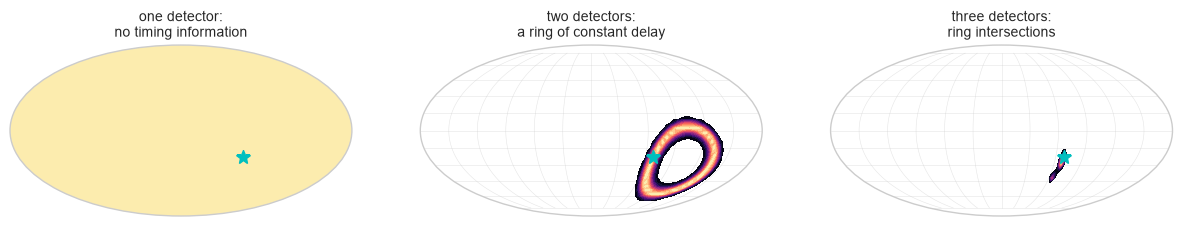

Sky area allowed by timing alone shrinks with each added detector.
One detector constrains direction only through its antenna pattern,
which is why a single-detector alert has a nearly all-sky map.


In [19]:
ra = np.linspace(-np.pi, np.pi, 91)
dec = np.linspace(-np.pi / 2, np.pi / 2, 46)
RA, DEC = np.meshgrid(ra, dec)
delays = {
    ifo.name: np.array(
        [[ifo.time_delay_from_geocenter(r, d, gps_time) for r in ra] for d in dec]
    )
    for ifo in ifos
}
observed = {
    ifo.name: ifo.time_delay_from_geocenter(
        source_parameters["ra"], source_parameters["dec"], gps_time
    )
    for ifo in ifos
}
sigma_t = 3e-4


def timing_likelihood(names):
    # With a single detector there is no arrival-time difference to form, so
    # the timing likelihood is flat: every direction is equally allowed.
    ref = names[0]
    value = np.zeros_like(RA)
    for name in names[1:]:
        value -= (
            0.5
            * (
                (delays[name] - delays[ref] - (observed[name] - observed[ref]))
                / sigma_t
            )
            ** 2
        )
    return value


panels = [
    (["H1"], "one detector:\nno timing information"),
    (["H1", "L1"], "two detectors:\na ring of constant delay"),
    (["H1", "L1", "V1"], "three detectors:\nring intersections"),
]
fig, axes = plt.subplots(
    1, 3, figsize=(15, 3.8), subplot_kw={"projection": "mollweide"}
)
for ax, (names, title) in zip(axes, panels):
    ll = timing_likelihood(names)
    sky = np.exp(ll - ll.max())
    ax.contourf(RA, DEC, sky, levels=np.linspace(0.05, 1, 15), cmap="magma")
    ax.plot(source_parameters["ra"], source_parameters["dec"], "c*", ms=10)
    ax.set_title(title, fontsize=10)
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
plt.show()
print("Sky area allowed by timing alone shrinks with each added detector.")
print("One detector constrains direction only through its antenna pattern,")
print("which is why a single-detector alert has a nearly all-sky map.")

<details>
<summary><i>Expected output &mdash; open this if your cell has not run yet</i></summary>

<img src="https://raw.githubusercontent.com/nz-gravity/FQCP2026_GW_data_analysis/assets/expected/lvk-sky-localisation.png" alt="expected output: lvk-sky-localisation" style="max-width:100%">

</details>

## Read or try next

- The [GWOSC Open Data Workshop](https://learn.gwosc.org/courses/odw2025)
  continues from strain conditioning to matched filtering and a data challenge.
- [Ripple documentation](https://ripplegw.readthedocs.io/) describes the
  differentiable waveform implementation used for the quantitative signals here.
- [Bilby's compact-binary tutorial](https://bilby-dev.github.io/bilby/compact-binary-coalescence-parameter-estimation.html)
  shows how detector data, waveform generation, priors, and the likelihood are
  assembled in a production-facing interface.

<!-- colab-badge-next -->
Next: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com/nz-gravity/FQCP2026_GW_data_analysis/blob/main/notebooks/03_lvk_gw150914_bilby.ipynb)

---

# Worked solutions

Everything above this line is the lab notebook, unchanged. Below are the
solutions to its exercises, as cells that actually run: execute the notebook
from the top and every variable they need will already exist.

## Code studio: a tiny template bank

In [20]:
def student_template_bank_scan(offsets):
    peaks = []
    for offset in offsets:
        trial = polarizations(theta_true.at[0].set(float(theta_true[0]) + offset))
        snr_series, _ = matched_filter(h1, trial)
        peaks.append(snr_series.max())
    return np.asarray(peaks)


bank = student_template_bank_scan(np.linspace(-2, 2, 9))
print("peak SNR per template:", np.round(bank, 1))
print(f"best offset: {np.linspace(-2, 2, 9)[np.argmax(bank)]:+.1f} Msun")

peak SNR per template: [15.4 16.9 18.9 20.6 21.7 21.4 20.6 18.8 17.7]
best offset: +0.0 Msun


## Question: how densely must a bank be packed?

In [21]:
peaks = np.asarray(recovered_peaks)
within = mismatch_offsets[peaks >= 0.97 * peaks.max()]
spacing = within.max() - within.min()
print(f"97% width: {spacing:.2f} Msun")
print(f"templates to cover 20-40 Msun: {int(np.ceil(20 / spacing))}")

97% width: 1.00 Msun
templates to cover 20-40 Msun: 21


The count is small here only because this is one parameter, at one mass, with a
Newtonian waveform. An O4 bank covers masses, mass ratio, and aligned spins
simultaneously and holds a few $10^5$ templates — which is why the matched
filter has to be an FFT rather than a loop.